In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


## ETL

In [ ]:
# performing

In [36]:
file_path = "./Datasets/healthData.csv"
try:
    df = pd.read_csv(file_path, na_values=["N/A"])
except FileNotFoundError:
    print("File not found.")
    df = None


if df is not None:
    gender_map = {"Female": 0, "Male": 1, "Other": 2}
    married_map = {"No": 0, "Yes": 1}
    residence_map = {"Rural": 0, "Urban": 1}
    work_type_map = {
    "Private": 0,
    "Self-employed": 1,
    "Govt_job": 2,
    "children": 3,
    "Never_worked": 4
}
smoking_map = {
    "never smoked": 0,
    "formerly smoked": 1,
    "smokes": 2,
    "Unknown": 0
}


risk_score = (
    (df["hypertension"] * 3.0) +          
    (df["heart_disease"] * 2.5) +         
    (df["avg_glucose_level"] * 0.02) +    
    (df["bmi"] * 0.015) +                 
    (df["age"] * 0.01) +                  
    (df["smoking_status"].isin(["smokes", "formerly smoked"]).astype(int) * 1.0)
)

# Create balanced target
threshold = risk_score.median()


df['stroke'] = (risk_score > threshold).astype(int)


print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100)
data = df.copy()

stroke
0    2656
1    2454
Name: count, dtype: int64
stroke
0    51.976517
1    48.023483
Name: proportion, dtype: float64


In [37]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,0
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [38]:
data.shape

(5110, 12)

In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [40]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.480235,0.499658,0.00,0.000,0.000,1.00,1.00


In [41]:
data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [42]:
data=data.drop(columns=['id'])

In [43]:
numeric_cols = data.select_dtypes(include=np.number).columns
categorical_cols = data.select_dtypes(include=['object', 'str']).columns

In [44]:
numeric_cols

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke'],
      dtype='str')

In [45]:
categorical_cols

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

In [46]:
for col in data.columns:
    print(col, data[col].unique())

gender <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
age [6.70e+01 6.10e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01
 5.90e+01 7.80e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 5.70e+01
 7.10e+01 5.20e+01 8.20e+01 6.50e+01 5.80e+01 4.20e+01 4.80e+01 7.20e+01
 6.30e+01 7.60e+01 3.90e+01 7.70e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01
 6.60e+01 5.10e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01
 1.32e+00 4.60e+01 3.20e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01
 3.50e+01 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01
 4.00e+00 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01
 3.30e+01 2.40e+01 3.40e+01 3.60e+01 6.40e-01 4.10e+01 8.80e-01 5.00e+00
 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01
 2.80e+01 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00
 1.00e+00 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-01 1.88e+00
 1.24e+00 8.00e-01 4.00e-01 8.00e-02 1.48e+00 5.6

In [47]:
binary_map = {
    "ever_married": {"No": 0, "Yes": 1},
    "Residence_type": {"Rural": 0, "Urban": 1}
}

In [48]:
for col, mapping in binary_map.items():
    data[col] = data[col].map(mapping)

In [49]:
data['gender']=data['gender'].map({"Female": 0, "Male": 1, "Other": 2})

In [50]:
data['bmi']=data['bmi'].fillna(data['bmi'].mean())

In [51]:
data['smoking_status'] = data['smoking_status'].replace("Unknown", data['smoking_status'].mode()[0])

In [52]:
# mapping for work_type and smoking_status
work_type_mapping = {
    "Private": 0,
    "Self-employed": 1,
    "Govt_job": 2,
    "children": 3,
    "Never_worked": 4
}

smoking_status_mapping = {
    "never smoked": 0,
    "formerly smoked": 1,
    "smokes": 2
}
data['work_type'] = data['work_type'].map(work_type_mapping)
data['smoking_status'] = data['smoking_status'].map(smoking_status_mapping)



In [53]:
data.isnull().sum().sum()

np.int64(0)

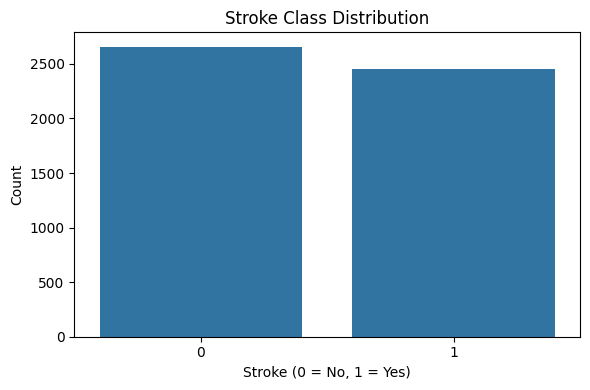

In [54]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Modeling


In [55]:
X = data.drop("stroke", axis=1)
y = data["stroke"]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

y_pred_lr_class = np.where(y_pred_lr >= 0.5, 1, 0)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_class))

Linear Regression
MSE: 0.1257221515551317
MAE: 0.28199565979321284
R2: 0.4963398585272756
Accuracy: 0.8659491193737769


In [58]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8884540117416829
ROC-AUC: 0.9506445587428707
[[493  38]
 [ 76 415]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       531
           1       0.92      0.85      0.88       491

    accuracy                           0.89      1022
   macro avg       0.89      0.89      0.89      1022
weighted avg       0.89      0.89      0.89      1022



In [59]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9549902152641878
ROC-AUC: 0.980567349772362
[[511  20]
 [ 26 465]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       531
           1       0.96      0.95      0.95       491

    accuracy                           0.95      1022
   macro avg       0.96      0.95      0.95      1022
weighted avg       0.96      0.95      0.95      1022



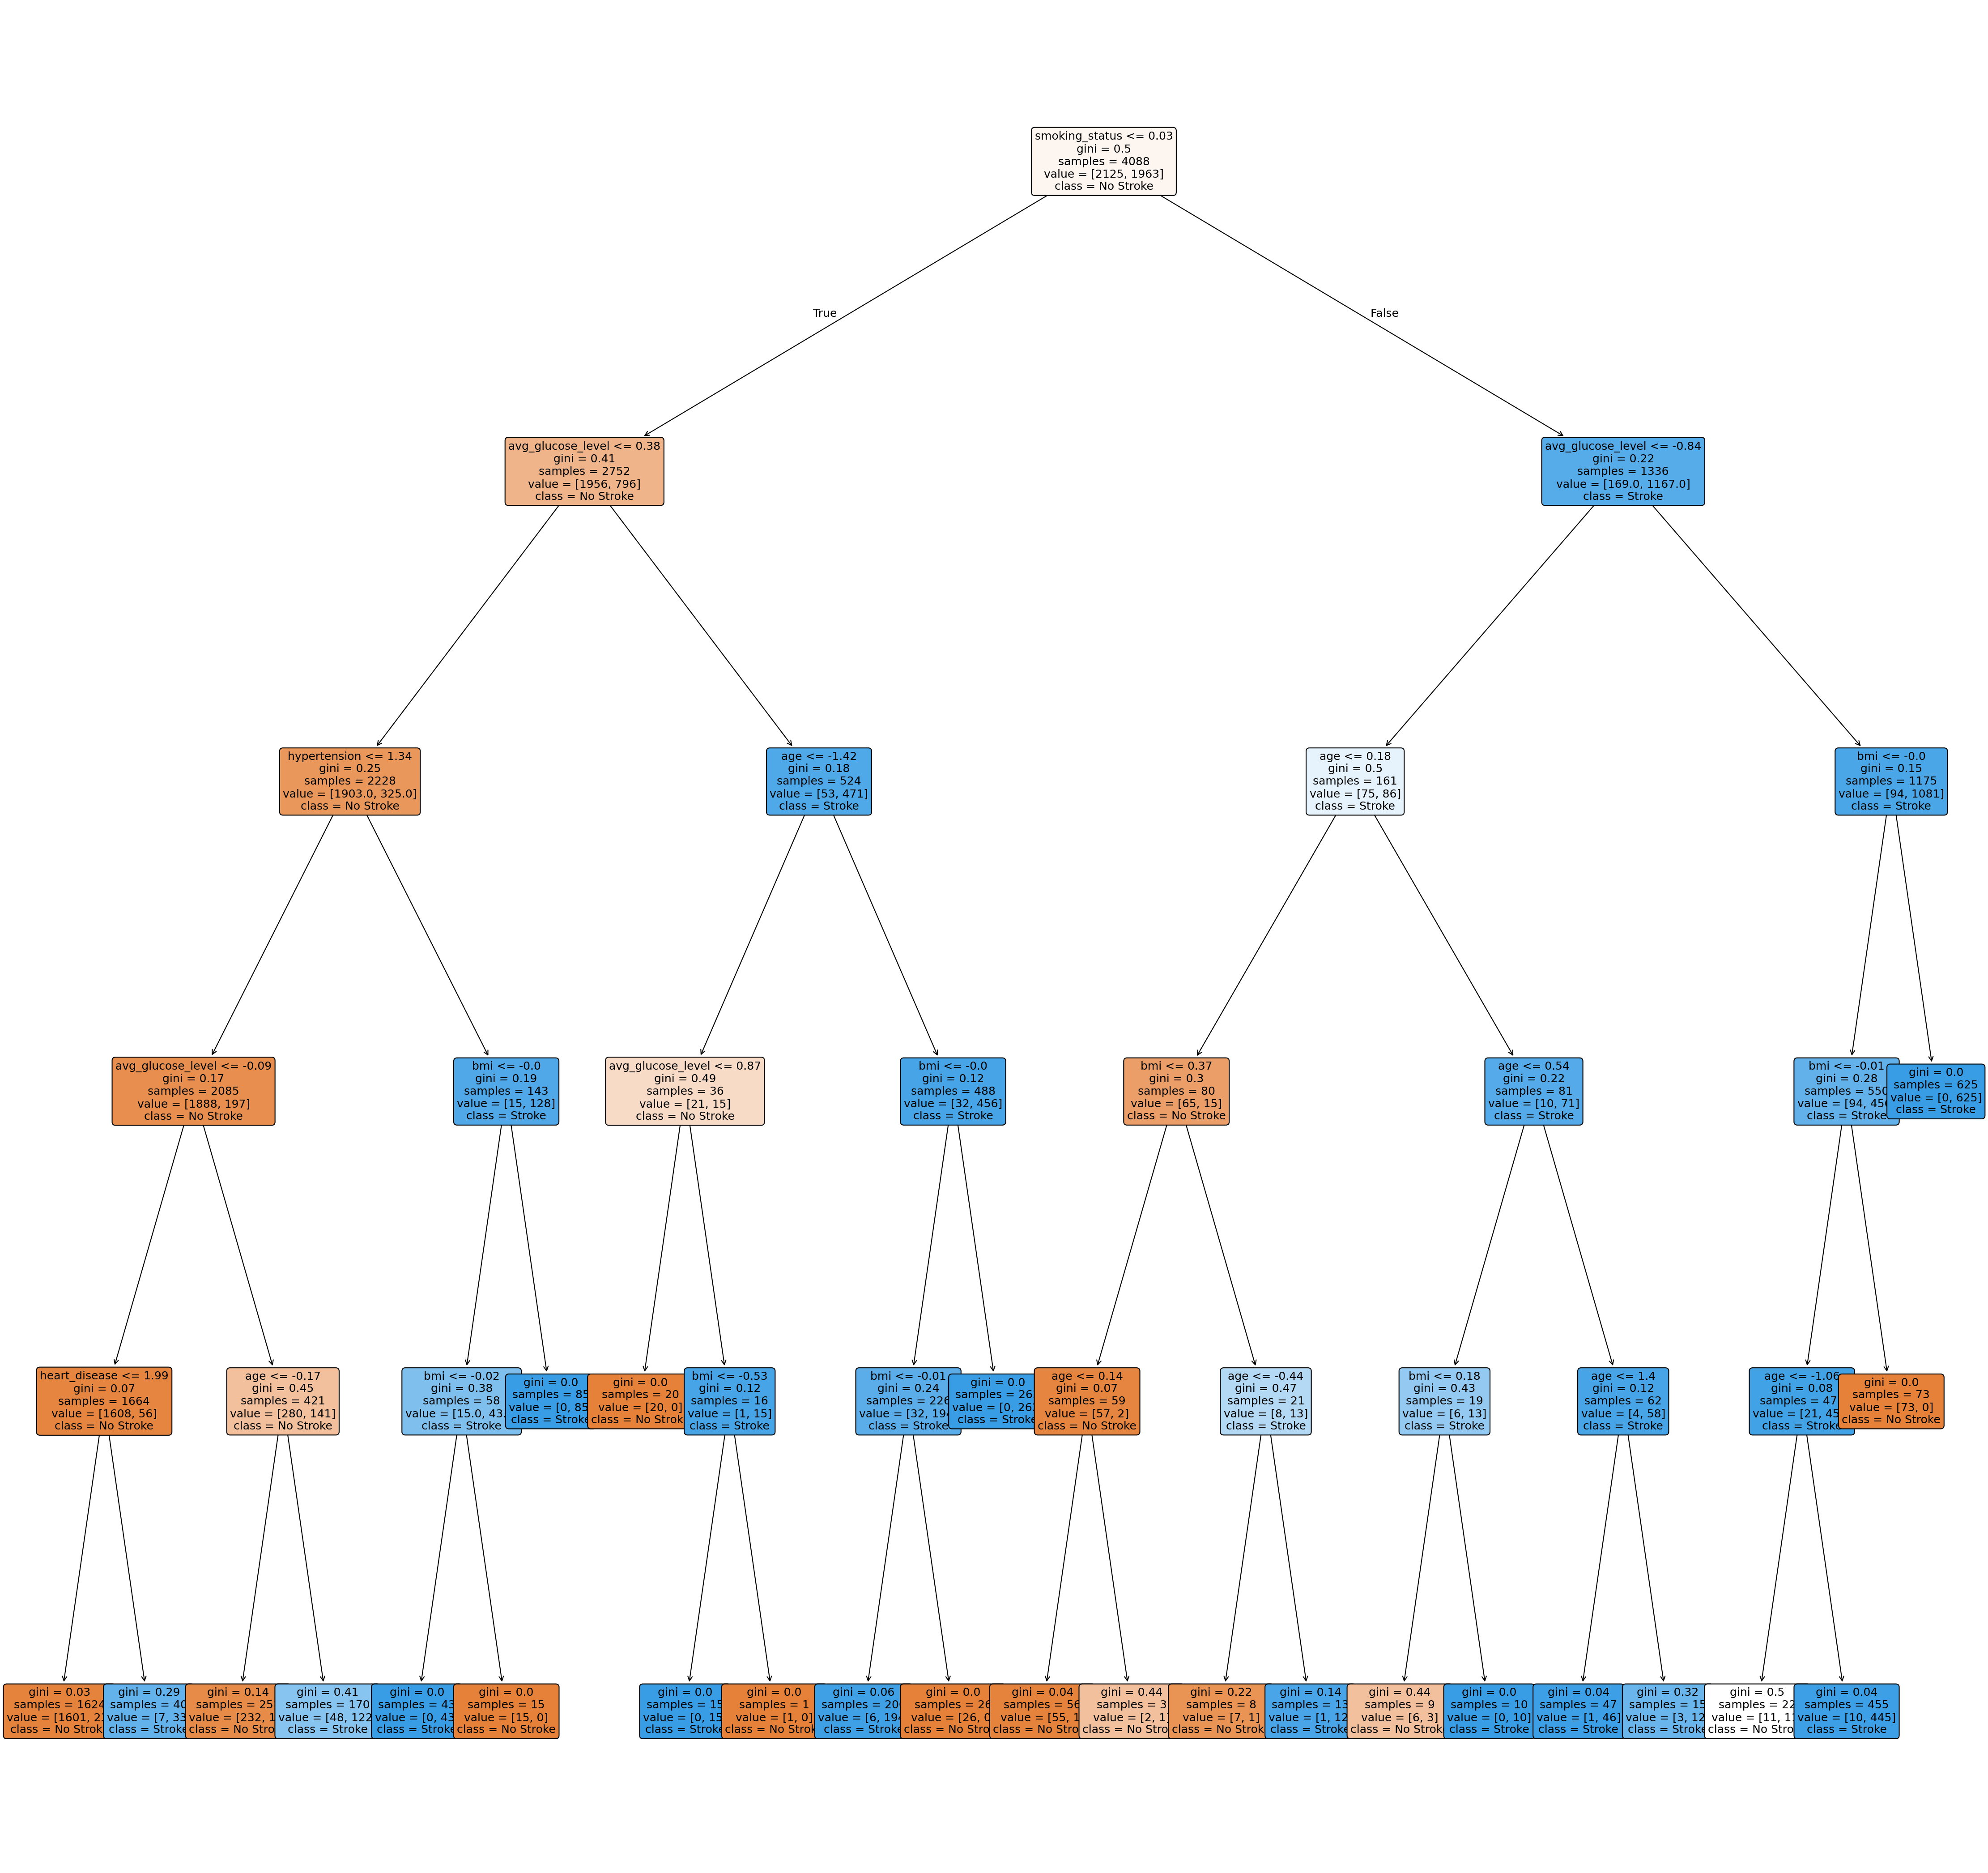

In [60]:
plt.figure(figsize=(30,28), dpi=150)
plot_tree(dt, filled=True, feature_names=X.columns, class_names=["No Stroke", "Stroke"],
          rounded=True, label='all', precision=2, fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9833659491193738
ROC-AUC: 0.9987400324484794
[[522   9]
 [  8 483]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       531
           1       0.98      0.98      0.98       491

    accuracy                           0.98      1022
   macro avg       0.98      0.98      0.98      1022
weighted avg       0.98      0.98      0.98      1022



Text(0.5, 1.0, 'Feature Importance from Random Forest')

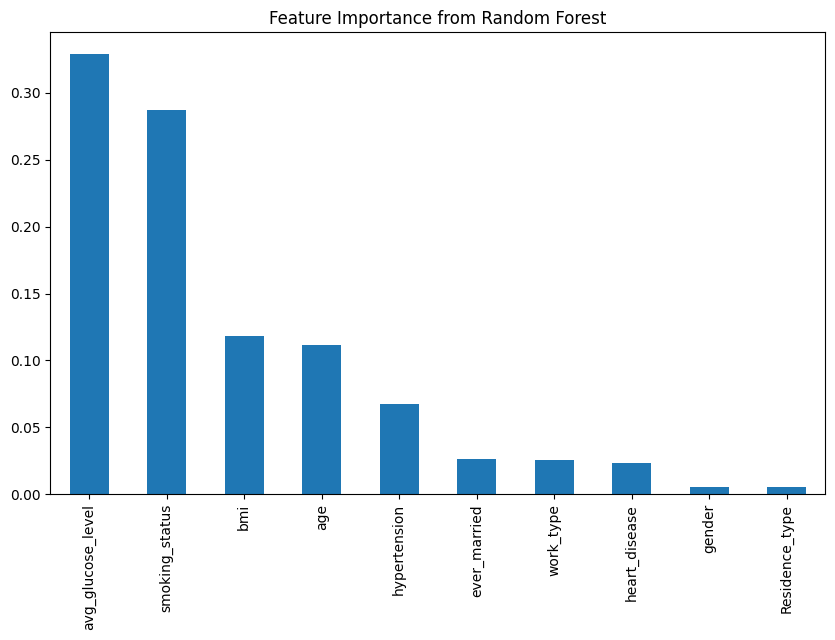

In [62]:
# feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importance from Random Forest")

In [63]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.910958904109589
ROC-AUC: 0.9595218643684245
[[490  41]
 [ 50 441]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       531
           1       0.91      0.90      0.91       491

    accuracy                           0.91      1022
   macro avg       0.91      0.91      0.91      1022
weighted avg       0.91      0.91      0.91      1022



In [64]:
# trying to predicting on new data using all models
new_data = pd.DataFrame({"gender": [1], "age": [65], "hypertension": [1], "heart_disease": [0],
                         "ever_married": [1], "work_type": [0], "Residence_type": [1], "avg_glucose_level": [150], "bmi": [30], "smoking_status": ["formerly smoked"]})

new_data['smoking_status'] = new_data['smoking_status'].map(smoking_status_mapping)
new_data_scaled = scaler.transform(new_data)

new_pred_lr = lr_model.predict(new_data_scaled)
new_pred_lr_class = np.where(new_pred_lr >= 0.5, 1, 0)

new_pred_logistic = lr.predict(new_data_scaled)

new_pred_dt = dt.predict(new_data_scaled)

new_pred_rf = rf.predict_proba(new_data_scaled)[:, 1]

new_pred_knn_label = knn.predict(new_data_scaled)
print("Predictions for new data:")
print("Linear Regression (probability):", new_pred_lr[0])
print("Linear Regression (class):", new_pred_lr_class[0])
print("Logistic Regression (class):", new_pred_logistic[0])
print("Decision Tree (class):", new_pred_dt[0])
print("Random Forest (probability of stroke):", new_pred_rf[0])
print("KNN (class):", new_pred_knn_label[0])


Predictions for new data:
Linear Regression (probability): 1.0608281102957262
Linear Regression (class): 1
Logistic Regression (class): 1
Decision Tree (class): 1
Random Forest (probability of stroke): 1.0
KNN (class): 1


### simple pipeline


In [65]:
gender_map = {"Female": 0, "Male": 1, "Other": 2}
married_map = {"No": 0, "Yes": 1}
residence_map = {"Rural": 0, "Urban": 1}
work_type_map = {"Private": 0, "Self-employed": 1, "Govt_job": 2, "children": 3, "Never_worked": 4}
smoking_map = {"never smoked": 0, "formerly smoked": 1, "smokes": 2, "Unknown": 0}

feature_cols = [
    "gender", "age", "hypertension", "heart_disease", "ever_married",
    "work_type", "Residence_type", "avg_glucose_level", "bmi", "smoking_status"
]

def preprocess_data(new_data):
    try:
        x = pd.DataFrame([new_data]).copy()

        x["gender"] = x["gender"].map(gender_map)
        x["ever_married"] = x["ever_married"].map(married_map)
        x["Residence_type"] = x["Residence_type"].map(residence_map)
        x["work_type"] = x["work_type"].map(work_type_map)
        x["smoking_status"] = x["smoking_status"].map(smoking_map)

        x = x[feature_cols]

        if x.isnull().any().any():
            raise ValueError("Invalid category found in input data.")

        x_scaled = scaler.transform(x)
        return x, x_scaled

    except Exception as e:
        print("Preprocessing Error:", e)
        return None, None


def model_predict(x, x_scaled):
    try:
        results = {
            "Linear Regression": int(lr_model.predict(x_scaled)[0] >= 0.5),
            "Logistic Regression": int(lr.predict(x_scaled)[0]),
            "Decision Tree": int(dt.predict(x_scaled)[0]),
            "Random Forest": int(rf.predict(x_scaled)[0]),
            "KNN": int(knn.predict(x_scaled)[0]),
        }
        return results

    except Exception as e:
        print("Prediction Error:", e)
        return None


def pipeline(new_data):
    try:
        x, x_scaled = preprocess_data(new_data)

        if x is None or x_scaled is None:
            return None

        print("Processed Data:")
        print(x)

        print("\nPredictions:")
        results = model_predict(x, x_scaled)
        print(results)

        return results

    except Exception as e:
        print("Pipeline Error:", e)
        return None

In [66]:
gender_map = {"Female": 0, "Male": 1, "Other": 2}
married_map = {"No": 0, "Yes": 1}
residence_map = {"Rural": 0, "Urban": 1}
work_type_map = {"Private": 0, "Self-employed": 1, "Govt_job": 2, "children": 3, "Never_worked": 4}
smoking_map = {"never smoked": 0, "formerly smoked": 1, "smokes": 2, "Unknown": 0}

feature_cols = [
    "gender", "age", "hypertension", "heart_disease", "ever_married",
    "work_type", "Residence_type", "avg_glucose_level", "bmi", "smoking_status"
]

def preprocess_data(new_data):
    try:
        x = pd.DataFrame([new_data]).copy()

        x["gender"] = x["gender"].map(gender_map)
        x["ever_married"] = x["ever_married"].map(married_map)
        x["Residence_type"] = x["Residence_type"].map(residence_map)
        x["work_type"] = x["work_type"].map(work_type_map)
        x["smoking_status"] = x["smoking_status"].map(smoking_map)

        x = x[feature_cols]

        if x.isnull().any().any():
            raise ValueError("Invalid category found in input data.")

        x_scaled = scaler.transform(x)
        return x, x_scaled

    except Exception as e:
        print("Preprocessing Error:", e)
        return None, None


def model_predict(x, x_scaled):
    try:
        results = {
            "Linear Regression": int(lr_model.predict(x_scaled)[0] >= 0.5),
            "Logistic Regression": int(lr.predict(x_scaled)[0]),
            "Decision Tree": int(dt.predict(x_scaled)[0]),
            "Random Forest": int(rf.predict(x_scaled)[0]),
            "KNN": int(knn.predict(x_scaled)[0]),
        }
        return results

    except Exception as e:
        print("Prediction Error:", e)
        return None


def pipeline(new_data):
    try:
        x, x_scaled = preprocess_data(new_data)

        if x is None or x_scaled is None:
            return None

        print("Processed Data:")
        print(x)

        print("\nPredictions:")
        results = model_predict(x, x_scaled)
        print(results)

        return results

    except Exception as e:
        print("Pipeline Error:", e)
        return None

In [67]:
new_data = {
    "gender": "Male",
    "age": 67,
    "hypertension": 0,
    "heart_disease": 1,
    "ever_married": "Yes",
    "work_type": "Private",
    "Residence_type": "Urban",
    "avg_glucose_level": 228.69,
    "bmi": 36.6,
    "smoking_status": "formerly smoked"
}

pipeline(new_data)

Processed Data:
   gender  age  hypertension  heart_disease  ever_married  work_type  \
0       1   67             0              1             1          0   

   Residence_type  avg_glucose_level   bmi  smoking_status  
0               1             228.69  36.6               1  

Predictions:
{'Linear Regression': 1, 'Logistic Regression': 1, 'Decision Tree': 1, 'Random Forest': 1, 'KNN': 1}


{'Linear Regression': 1,
 'Logistic Regression': 1,
 'Decision Tree': 1,
 'Random Forest': 1,
 'KNN': 1}